# numpy 라이브러리 이해

- 통계, 분석, AI 분야의 라이브러리 내부에 다양한 수치연산이 필요함
  + 수치연산을 얼마나 효율적으로 처리하는가에 따라 성능에 많은 영향을 줌
  + numpy 는 ndarray 라는 자료를 바탕으로 강력한 연산 기능을 제공함
- numpy 와 다른 python 패키지와의 관계
  ![nn](./images/numpy-01.png)

# ndarray 성능 확인

In [1]:
import numpy as np

In [2]:
a = [1, 2, 3]
b = [4, 5, 6]
c = []

for a, b in zip(a, b):
    c.append(a+b)
    
print(c)

[5, 7, 9]


In [3]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
c = a + b

print(c)

[5 7 9]


In [4]:
a = [[1,2,3,4] for _ in range(1000000)]
b = np.array(a)

def exchange_list(a):
    c = []
    for x in a:
        x[2], x[3], x[0], x[1] = x
        c.append(x)
    return c

def exchange_ndarray(a):
    return a[ : , [2, 3, 0, 1]]

In [5]:
print(a[:2], b[:2], sep='\n')

[[1, 2, 3, 4], [1, 2, 3, 4]]
[[1 2 3 4]
 [1 2 3 4]]


In [6]:
c = exchange_list(a)

In [7]:
d = exchange_ndarray(b)

In [8]:
print(c[:2], d[:2], sep='\n')

[[3, 4, 1, 2], [3, 4, 1, 2]]
[[3 4 1 2]
 [3 4 1 2]]


In [9]:
%timeit exchange_list(a)

128 ms ± 659 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [10]:
%timeit exchange_ndarray(b)

4.26 ms ± 546 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


# ndarray 가 list 보다 빠른 이유

- numpy 의 ndarray와 built-in list 의 데이터 접근 방법 차이

![nn](./images/numpy-02.png)

https://github.com/numpy/numpy/blob/maintenance/1.7.x/numpy/core/include/numpy/ndarraytypes.h#L646
https://hg.python.org/cpython/file/3.6/Include/listobject.h#l23
https://hg.python.org/cpython/file/3.6/Include/longintrepr.h/#l85

# ndarray 의 속성

In [11]:
import numpy as np

In [12]:
def printinfo(a):
    data = ['a.ndim', 'a.shape', 'a.size', 'a.dtype', 'a.itemsize', 'a.strides', 'a.nbytes']
    for x in data:
        print('%-11s' % x, eval(x))

a = np.array([[0,1,2], [3,4,5]], dtype=np.int32)
printinfo(a)

a.ndim      2
a.shape     (2, 3)
a.size      6
a.dtype     int32
a.itemsize  4
a.strides   (12, 4)
a.nbytes    24


# ndarray 생성 - np.array()

In [13]:
import numpy as np

In [14]:
def printary(*a):
    for x in a:
        print(f'{type(x)}\n{x.dtype}\n{x}', end='\n\n')
    print("-" * 30)

In [15]:
a = np.array([1,2,3])
b = np.array([[1,2,3], [4,5,6]])
c = np.array([[1,2,3], [4,5]])
printary(a, b, c)

<class 'numpy.ndarray'>
int64
[1 2 3]

<class 'numpy.ndarray'>
int64
[[1 2 3]
 [4 5 6]]

<class 'numpy.ndarray'>
object
[list([1, 2, 3]) list([4, 5])]

------------------------------


/var/folders/3k/bgnrnfc15w792712mgb6g0_c0000gn/T/ipykernel_19622/3341886738.py:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  c = np.array([[1,2,3], [4,5]])


# structured array - np.array()

- ndarray 가 모든 element를 동일 type 으로 하지 않고, column 별로 다른 type 을 사용하는 구조
- 하기 예시는 Big Endian, Little Endian 을 참조할 것
- 권장하지 않음

In [16]:
sdtype = [('name', '<U10'), ('height', '<i4'), ('weight', np.float32)]
value =  [('Tome', 178, 98.5), ('Jim', 183, 79.5), ('Adam', 175, 82.8)]

a = np.array(value, dtype=sdtype)

printary(a)

<class 'numpy.ndarray'>
[('name', '<U10'), ('height', '<i4'), ('weight', '<f4')]
[('Tome', 178, 98.5) ('Jim', 183, 79.5) ('Adam', 175, 82.8)]

------------------------------


In [17]:
printary(a['name'], a['height'], a['weight'])
printary(a[0], a[1], a[2])
print(a.shape, a.strides, a[0])

<class 'numpy.ndarray'>
<U10
['Tome' 'Jim' 'Adam']

<class 'numpy.ndarray'>
int32
[178 183 175]

<class 'numpy.ndarray'>
float32
[98.5 79.5 82.8]

------------------------------
<class 'numpy.void'>
[('name', '<U10'), ('height', '<i4'), ('weight', '<f4')]
('Tome', 178, 98.5)

<class 'numpy.void'>
[('name', '<U10'), ('height', '<i4'), ('weight', '<f4')]
('Jim', 183, 79.5)

<class 'numpy.void'>
[('name', '<U10'), ('height', '<i4'), ('weight', '<f4')]
('Adam', 175, 82.8)

------------------------------
(3,) (48,) ('Tome', 178, 98.5)


# ndarray 생성 - np.arange()

In [18]:
a = np.arange(5)
b = np.arange(1, 10, 2)
c = np.arange(1, 2, 0.1)

printary(a, b, c)

<class 'numpy.ndarray'>
int64
[0 1 2 3 4]

<class 'numpy.ndarray'>
int64
[1 3 5 7 9]

<class 'numpy.ndarray'>
float64
[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9]

------------------------------


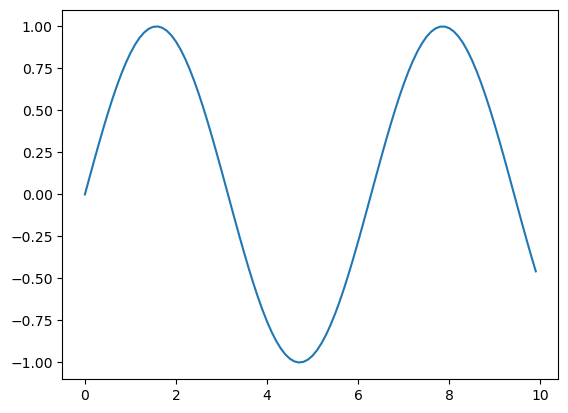

In [19]:
# 그래프를 그릴 때 축설정으로 사용 예
import matplotlib.pyplot as plt

x = np.arange(0, 10, 0.1)
y = np.sin(x)

plt.plot(x, y)

plt.show()

# ndarray 생성 - np.linspace()

- linear space 라고 읽는다!
- np.linspace(start: array_like, stop, num=50, endpoint=True, retstep=False, dtype=None)

In [20]:
x = np.array(1) # 1개만 있는 값도 (scalar) array-like 임
print(x, type(x))

1 <class 'numpy.ndarray'>


In [21]:
a = np.linspace(1, 5, 9) # 1부터 5까지 9개의 원소를 가는 array, 간격은 알아서 결정
b = np.linspace(1, 5, 10, endpoint=False)
c, step = np.linspace(1, 5, 9, retstep=True)  # c가 array, d 가 step

print(a, b, c, step, sep='\n')

[1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
[1.  1.4 1.8 2.2 2.6 3.  3.4 3.8 4.2 4.6]
[1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
0.5


In [22]:
x = np.linspace([1,2,3], [2,4,6], num=5)
print(x)

[[1.   2.   3.  ]
 [1.25 2.5  3.75]
 [1.5  3.   4.5 ]
 [1.75 3.5  5.25]
 [2.   4.   6.  ]]


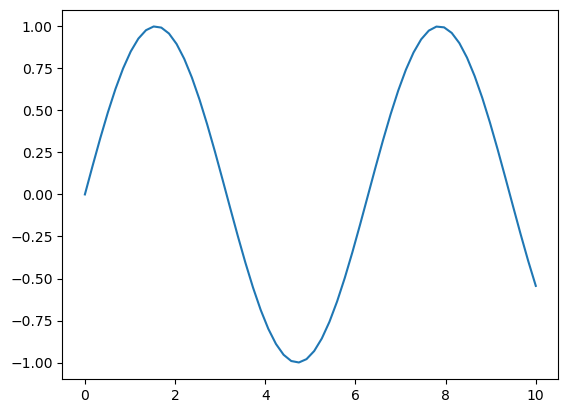

In [23]:
x = np.linspace(0, 10, 60)
y = np.sin(x)

plt.plot(x, y)
plt.show()

# random 사용

- `np.random.rand(d0, d1, ... dn)`
    + 0 ~ 1 사이의 균등 분포로 실수 난수 배열 생성
    + d0, d1, ... dn : 배열의 shape 의 의미하는 정수
- `np.random.randint(e, size=n)`, `np.random.randint(s, e, size=n)`
    + 0 ~ $e-1$, s ~ $e-1$ 범위의 값을 갖는 균등 분포의 정수 난수 생성
    + size: 정수(1차원), tuple(1차원 이상)로 shape 을 지정
- `np.random.randn(d0, d1, ... dn)`
    + 평균 0, 표준편차 1을 갖는 가우시안 정규분포로 난수 배열 생성 (음수 포함)
- `np.random.normal(평균, 표준편차, size)`
    + 생략하면 평균 = 0, 표준편차 = 1, size = 1
- `np.random.permutation(e)` : 0 ~ e-1 값을 갖는 정수의 무작위 순서 1차원 배열 생성
- `np.random.permutation(c)` : c 요소들에 대해 무작위 순서로 변경된 1차원 배열 생성
    + e: 정수, c : array_like 객체

In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
np.set_printoptions(threshold=999, 
                    suppress=True, 
                    precision=4, 
                    edgeitems=3)

In [26]:
def printary(*a):
    for x in a:
        print(f"shape: {x.shape}")
        print(f"array: %s{x}" % ('' if x.ndim == 1 else '\n'))
        print("mean : %.3f, std: %.3f" % (x.mean(), x.std()))
        print("-" * 30)

In [27]:
def showHist(x):
    plt.hist(x)
    plt.show()

In [28]:
a = np.random.rand(5)
b = np.random.rand(2, 2, 3)

printary(a, b)

shape: (5,)
array: [0.4771 0.1979 0.7772 0.9891 0.8119]
mean : 0.651, std: 0.280
------------------------------
shape: (2, 2, 3)
array: 
[[[0.1322 0.402  0.5137]
  [0.7095 0.8735 0.8703]]

 [[0.294  0.2732 0.5945]
  [0.0874 0.7422 0.8749]]]
mean : 0.531, std: 0.278
------------------------------


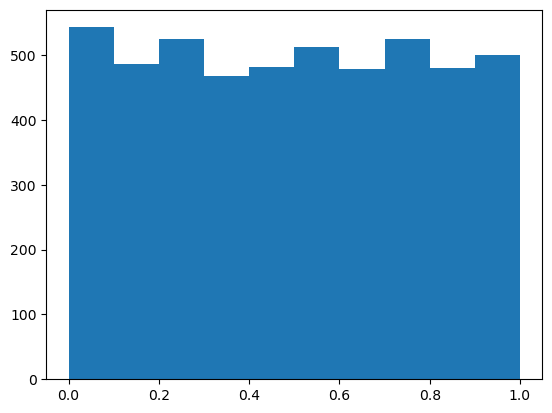

In [29]:
showHist(np.random.rand(5000))

In [30]:
a = np.random.randint(10, size=(5,))
b = np.random.randint(50, 100, (2, 4))

printary(a, b)

shape: (5,)
array: [2 4 4 6 0]
mean : 3.200, std: 2.040
------------------------------
shape: (2, 4)
array: 
[[70 61 79 51]
 [94 98 72 58]]
mean : 72.875, std: 15.672
------------------------------


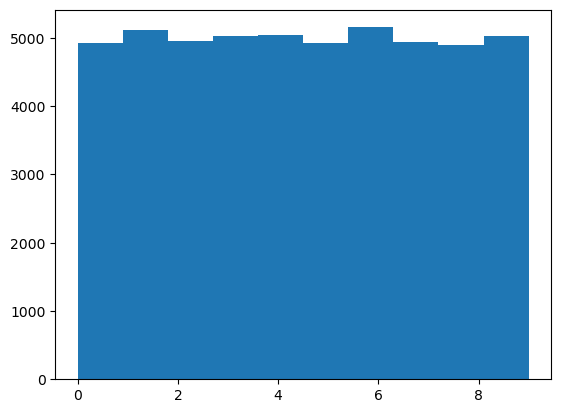

In [31]:
showHist(np.random.randint(10, size=50000))

In [32]:
a = np.random.randn(5)
b = np.random.randn(200, 50)

printary(a, b)

shape: (5,)
array: [-0.9922  0.4663 -0.0928  0.6697  0.1568]
mean : 0.042, std: 0.579
------------------------------
shape: (200, 50)
array: 
[[-0.0529  2.7208  1.5253 ...  0.3308  0.7384 -0.6524]
 [-1.2999  0.4546 -0.41   ... -1.6146 -0.6121  0.5043]
 [-0.0388 -0.4527  1.1412 ... -0.9017  0.924   0.8048]
 ...
 [-1.0654  0.9987 -0.1121 ... -0.5547  0.6495  0.1886]
 [-0.6351  1.0422 -1.5605 ...  0.3713 -1.0644 -0.5478]
 [ 1.1943 -0.3785 -1.1576 ... -0.9559  0.0299 -1.4323]]
mean : 0.008, std: 0.996
------------------------------


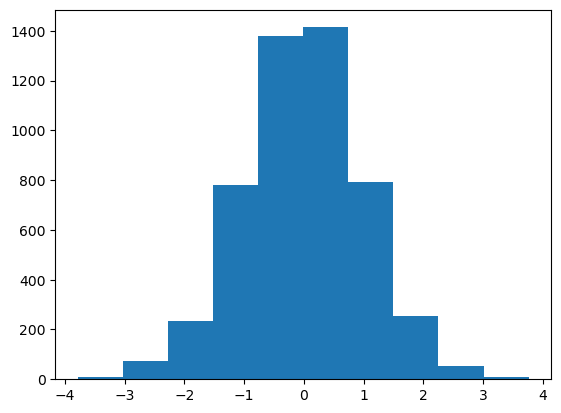

In [33]:
showHist(np.random.randn(5000))

In [34]:
a = np.random.normal(2, 3, (100, 20))

printary(a)

shape: (100, 20)
array: 
[[ 9.4865 -0.7417  0.3102 ...  2.6169 -0.5894 -0.0337]
 [ 5.3679  1.9433  2.7854 ...  0.9896  2.8065  0.8348]
 [-7.6553  1.6705  0.5082 ...  3.4636 -2.1461  2.0965]
 ...
 [ 2.0023  2.3732  1.0623 ...  3.7926 -0.5782  4.4339]
 [ 8.8068 -0.7687  3.9807 ...  3.4288  1.5917 -0.4845]
 [ 4.3769  6.8012  2.5266 ...  8.0166  1.4648 -1.827 ]]
mean : 2.006, std: 3.044
------------------------------


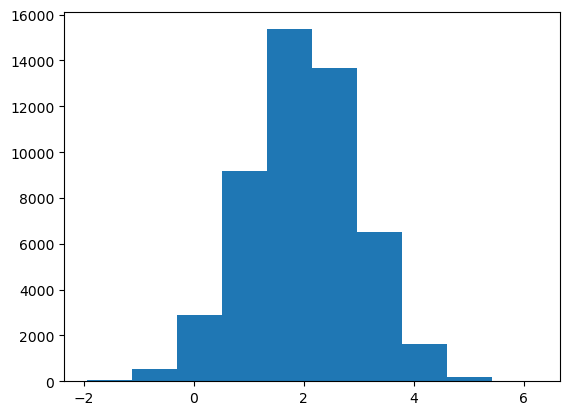

In [35]:
showHist(np.random.normal(2, 1, (50000,)))

In [36]:
a = np.random.permutation(10)
data = np.array([1,3,4,5,3,1,3])
b = np.random.permutation(data)
mylist = [[1,2,3], [4,5,6], [7,8,9], [3,2,1]]
c = np.random.permutation(mylist)

printary(a, b, c)

shape: (10,)
array: [9 6 8 1 5 2 0 3 4 7]
mean : 4.500, std: 2.872
------------------------------
shape: (7,)
array: [3 3 1 1 5 3 4]
mean : 2.857, std: 1.355
------------------------------
shape: (4, 3)
array: 
[[4 5 6]
 [1 2 3]
 [7 8 9]
 [3 2 1]]
mean : 4.250, std: 2.618
------------------------------


# 특정값으로 채워진 ndarray 생성

In [37]:
import numpy as np

In [38]:
def printary(*a):
    for x in a:
        print(f'{x.dtype}\n{x}')
        print("-" * 30)

In [39]:
mshape = (2, 3)

In [40]:
a = np.zeros(10, dtype=np.int32)
b = np.zeros(mshape)

printary(a, b)

int32
[0 0 0 0 0 0 0 0 0 0]
------------------------------
float64
[[0. 0. 0.]
 [0. 0. 0.]]
------------------------------


In [41]:
a = np.empty(10, dtype=np.int32)
b = np.empty(mshape)

printary(a, b)

int32
[          0 -1073741824           0           0           0  1073741824
           0  1074790400           0  1075314688]
------------------------------
float64
[[0. 0. 0.]
 [0. 0. 0.]]
------------------------------


In [42]:
a = np.ones(mshape)
b = np.full(mshape, 5)

printary(a, b)

float64
[[1. 1. 1.]
 [1. 1. 1.]]
------------------------------
int64
[[5 5 5]
 [5 5 5]]
------------------------------


In [43]:
a = np.eye(3)
b = np.eye(3, 5, 2)
c = np.eye(3, 5, -1)
d = np.identity(3)

printary(a, b, c, d)

float64
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
------------------------------
float64
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
------------------------------
float64
[[0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
------------------------------
float64
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
------------------------------


In [44]:
a = np.zeros_like([1,2,3])
b = np.empty_like([1,2,3])

printary(a, b)

int64
[0 0 0]
------------------------------
int64
[4611686018427387904 4616189618054758400 4618441417868443648]
------------------------------


In [45]:
a = np.ones_like([[1,2,3], [4,5,6]], dtype=np.float32)
b = np.full_like(np.arange(5), 10)

printary(a, b)

float32
[[1. 1. 1.]
 [1. 1. 1.]]
------------------------------
int64
[10 10 10 10 10]
------------------------------


# copy & view 객체

- ndarray 의 copy 객체 또는 view 객체의 특징
![nn](./images/numpy-03.png)

## The Array Interface (Arrary Protocol)
- 배열 인터페이스는 dictionary 구조로 필수 3개, 옵션 5개의 Key 가 있음
- 필수 : shape, typestr, version
- 옵션 : descr, data, strides, mask, offset
    + data : 저장 영역의 메모리 주소 정보, read-only flag
    + ndarray 의 저장공간 메모리 주소: `arr.__array_interface__['data'][0]`

![nn](./images/numpy-04.png)

In [46]:
def npinfo(n, a, x):
    print("name:     :", n)
    print("share:    :", np.may_share_memory(a, x))
    print("data:     :", x.tolist())
    print("ndim:     :", x.ndim)
    print("shape:    :", x.shape)
    print("dtype:    :", x.dtype)
    print("-" * 30)

In [47]:
a = np.array([[True, True], [False, False]], dtype=np.bool8)
b = a.copy()
b[0, 0] = False

npinfo("original", a, a)
npinfo("copy", a, b)

name:     : original
share:    : True
data:     : [[True, True], [False, False]]
ndim:     : 2
shape:    : (2, 2)
dtype:    : bool
------------------------------
name:     : copy
share:    : False
data:     : [[False, True], [False, False]]
ndim:     : 2
shape:    : (2, 2)
dtype:    : bool
------------------------------


In [48]:
a = np.array([[True, True], [False, False]], dtype=np.bool8)
b = a.view(dtype=np.bool8)
b[0, 0] = 0

npinfo("original", a, a)
npinfo("view", a, b)

name:     : original
share:    : True
data:     : [[False, True], [False, False]]
ndim:     : 2
shape:    : (2, 2)
dtype:    : bool
------------------------------
name:     : view
share:    : True
data:     : [[False, True], [False, False]]
ndim:     : 2
shape:    : (2, 2)
dtype:    : bool
------------------------------


# ndarray 변환 (reshape, flatten)

- `np.reshape(a, newshape: int or tuple or ints, order='C')`
- `arr.reshape(newshape: int or tuple or ints, order='C')`
    + order : C - C Language/행우선 처리, F - Fortran/열우선 처리
- reshape : View 반환
- flatten, astype : copy 반환

In [49]:
import sys

def npinfo(n, a, x):
    print("name:     :", n)
    print("share:    :", np.may_share_memory(a, x))
    print("data:     :", x.tolist())
    print("shape:    :", x.shape)
    print("dtype:    :", x.dtype)
    print("stride:   :", x.strides)
    print("addr:     :", x.__array_interface__['data'][0])
    print("sizeof    :", sys.getsizeof(x))
    print("-" * 30)

In [50]:
a = np.array([[1,2,3], [4,5,6]], dtype=np.int64)
b = a.reshape(1, -1)

npinfo("a.reshape(1, -1)", a, b)

name:     : a.reshape(1, -1)
share:    : True
data:     : [[1, 2, 3, 4, 5, 6]]
shape:    : (1, 6)
dtype:    : int64
stride:   : (48, 8)
addr:     : 105553167549424
sizeof    : 128
------------------------------


In [51]:
b = a.reshape(-1)

npinfo("a.reshape(-1)", a, b)

name:     : a.reshape(-1)
share:    : True
data:     : [1, 2, 3, 4, 5, 6]
shape:    : (6,)
dtype:    : int64
stride:   : (8,)
addr:     : 105553167549424
sizeof    : 112
------------------------------


In [52]:
b = a.reshape(-1, 1)

npinfo("a.reshape(-1, 1)", a, b)

name:     : a.reshape(-1, 1)
share:    : True
data:     : [[1], [2], [3], [4], [5], [6]]
shape:    : (6, 1)
dtype:    : int64
stride:   : (8, 8)
addr:     : 105553167549424
sizeof    : 128
------------------------------


In [53]:
b = a.reshape(-1, 1, order='F')

npinfo("a.reshape(-1, 1, order='F')", a, b)

name:     : a.reshape(-1, 1, order='F')
share:    : False
data:     : [[1], [4], [2], [5], [3], [6]]
shape:    : (6, 1)
dtype:    : int64
stride:   : (8, 48)
addr:     : 105553167549040
sizeof    : 128
------------------------------


In [54]:
b = a.flatten()

npinfo("a.flatten()", a, b)

name:     : a.flatten()
share:    : False
data:     : [1, 2, 3, 4, 5, 6]
shape:    : (6,)
dtype:    : int64
stride:   : (8,)
addr:     : 105553167549520
sizeof    : 160
------------------------------


In [55]:
a = np.array([[1,2,3], [4,5,6]], dtype=np.float64)
b = a.astype(np.int32)

npinfo("a.astype(np.int32)", a, b)

name:     : a.astype(np.int32)
share:    : False
data:     : [[1, 2, 3], [4, 5, 6]]
shape:    : (2, 3)
dtype:    : int32
stride:   : (12, 4)
addr:     : 105553182278560
sizeof    : 152
------------------------------


# ndarray 산술연산 - element-wise 방식의 이해

- element-wise 방식 연산 : 동일한 Shape 을 가진 배열의 연산 -> 같은 Index 에 위치한 요소를 연산
- broadcasting : element-wise 성립하지 않는 경우 두 배열의 크기를 동일하게 만들어 연산가능하도록 하는 것

In [56]:
a = np.array(range(1, 7))
b = np.array(range(7, 13))

print('a = ', a)
print('b = ', b)

print('a + b = ', a + b)
print('b - a = ', b - a)
print('a * b = ', a * b)
print('b / a = ', b / a)
print('b // a = ', b // a)
print('b % a = ', b % a)

print('a + 2 = ', a + 2)
print('b - 1 = ', b - 1)

a =  [1 2 3 4 5 6]
b =  [ 7  8  9 10 11 12]
a + b =  [ 8 10 12 14 16 18]
b - a =  [6 6 6 6 6 6]
a * b =  [ 7 16 27 40 55 72]
b / a =  [7.  4.  3.  2.5 2.2 2. ]
b // a =  [7 4 3 2 2 2]
b % a =  [0 0 0 2 1 0]
a + 2 =  [3 4 5 6 7 8]
b - 1 =  [ 6  7  8  9 10 11]


In [57]:
a = np.array(range(1, 7)).reshape(2, 3)
b = np.array(range(7, 13)).reshape(2, 3)

print(a)
print(b)
print(type(a.tolist()))
print('a = ', a.tolist())
print('b = ', b.tolist())

print('a + b = ', (a + b).tolist())
print('a * b = ', (a * b).tolist())

[[1 2 3]
 [4 5 6]]
[[ 7  8  9]
 [10 11 12]]
<class 'list'>
a =  [[1, 2, 3], [4, 5, 6]]
b =  [[7, 8, 9], [10, 11, 12]]
a + b =  [[8, 10, 12], [14, 16, 18]]
a * b =  [[7, 16, 27], [40, 55, 72]]


In [58]:
# element-wise 가 성립되지 않음 (broadcasting 안 됨)
a = np.array([1,3,5])
c = np.array([7,9])

print('a + c = ', a + c)

ValueError: operands could not be broadcast together with shapes (3,) (2,) 

# ndarray 산술연산 - broadcasting 의 이해

1. Scalar 값은 상대 배열의 shape 와 같은 shape, 동일 값으로 배열이 된다
2. 한 배열 shape 이 다른 배열 shape 의 부분 shape 이면 차원이 높은 shape 를 따른다
    + (4,2,3,1) 의 부분 shape 예시 : (2,3,1), (3,1), (1,)
3. 요소 갯수가 1인 차원에 한해서는 다른 배열의 동일 차원을 요수 수를 따른다
    + (5, 1) shape 을 가진 배열과 (1, 3) shape 을 가진 배열 -> (5, 3)과 (5, 3) 의 연산

In [59]:
import pprint as pp

def printary(m, *a):
    print(m)
    for x in a:
        print(x.shape, end=" : ")
        print(x.tolist())
    print("-" * 30)

In [60]:
a = np.array([[1,1,1], [1,1,1]])
b = np.array([[1,1,1], [2,2,2]])
c = np.array([[1], [2], [3]])
d = np.array([3,3,3])

print(a.shape, b.shape, c.shape, d.shape)

(2, 3) (2, 3) (3, 1) (3,)


In [61]:
printary("a+b", a, b, a+b)

a+b
(2, 3) : [[1, 1, 1], [1, 1, 1]]
(2, 3) : [[1, 1, 1], [2, 2, 2]]
(2, 3) : [[2, 2, 2], [3, 3, 3]]
------------------------------


In [62]:
# a는 (2, 3) shape 이므로  d (3, ) 은 부분 shape 임
printary("a+d", a, d, a+d)

a+d
(2, 3) : [[1, 1, 1], [1, 1, 1]]
(3,) : [3, 3, 3]
(2, 3) : [[4, 4, 4], [4, 4, 4]]
------------------------------


In [63]:
printary("b+4", b, b+4)

b+4
(2, 3) : [[1, 1, 1], [2, 2, 2]]
(2, 3) : [[5, 5, 5], [6, 6, 6]]
------------------------------


In [64]:
printary("c+d", c, d, c+d)

c+d
(3, 1) : [[1], [2], [3]]
(3,) : [3, 3, 3]
(3, 3) : [[4, 4, 4], [5, 5, 5], [6, 6, 6]]
------------------------------


# ndarray 비교 연산

- ==, !=, >, <, >=, <=: 결과 True / False
- element-wise 방식 (필요 시 broadcasting)

In [65]:
a = np.array([[1], [2], [3], [4], [5]])
b = np.array([1,2,3])
c = a + b
print(a.shape, b.shape, c.shape)

(5, 1) (3,) (5, 3)


In [66]:
print(a)
print(b)
print(c)

[[1]
 [2]
 [3]
 [4]
 [5]]
[1 2 3]
[[2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]
 [6 7 8]]


In [67]:
def printary(*a):
    for x in a:
        print(x.tolist(), end="\n")
        print("-" * 45)

In [68]:
a = np.array([[1,2,3], [4,5,6]])
b = np.array([[1,3,5], [2,4,6]])
printary(a == b, b != a)

[[True, False, False], [False, False, True]]
---------------------------------------------
[[False, True, True], [True, True, False]]
---------------------------------------------


In [69]:
a = np.array([[1,2,3], [4,5,6]])
b = np.array([[1,3,5], [2,4,6]])
printary(a > b, a < b)

[[False, False, False], [True, True, False]]
---------------------------------------------
[[False, True, True], [False, False, False]]
---------------------------------------------


In [70]:
a = np.array([[1,2,3], [4,5,6]])
b = np.array([[1,3,5], [2,4,6]])
c = np.array([4,3,3])
printary(a >= c, b <= 3)

[[False, False, True], [True, True, True]]
---------------------------------------------
[[True, True, False], [True, False, False]]
---------------------------------------------


# ndarray indexing 이해

- indexing을 사용하여 배열에서 원하는 데이터를 참조/변경하다.
- 배열 이름 뒤에 [] 를 사용하여 참조/변경할 데이터를 표기한다.
- 결과는 원본의 View 이며, View 에 대입을 통해 데이터 변경이 가능함
- ndim >= 2 인 경우 [] 내부에 콤마(,)를 사용하여 차원 (축, axis, axes) 을 구분함
- 콤마(,) 사이에는 참조/변경하기 원하는 데이터에 대한 표기(indexer)가 포함되어야 함
- axis=0 을 제외한 차원에 대한 표기 생략 가능, 생략은 "모두 선택"의 의미를 갖음

In [71]:
import numpy as np

In [72]:
a = np.arange(9).reshape(3,3)

print(a)
print(a[1])
print(a[0,2])
print(a[0][2])

[[0 1 2]
 [3 4 5]
 [6 7 8]]
[3 4 5]
2
2


In [73]:
a[0,2] = 100
print(a, a.dtype)

a[1][2] = 200
print(a)

a[2] = [10, '20', 3.14]
print(a)

[[  0   1 100]
 [  3   4   5]
 [  6   7   8]] int64
[[  0   1 100]
 [  3   4 200]
 [  6   7   8]]
[[  0   1 100]
 [  3   4 200]
 [ 10  20   3]]


# Indexer 의 종류

- single element index
- slicing & stride index
- index arrays : 배열의 형태 (list or ndarray)
- boolean index : True / False 로 구성된 배열의 형태, 단 기존 배열과 구조가 동일하여야 함
- structural indexing tools
    + `...` : 전체
    + `np.newaxis` : 차원을 증가

In [74]:
a = np.arange(5)

print(a[1], type(a[1]))
print(a[[1]], type(a[[1]]))                   # index array
print(a[1:4:2])
print(a[[0,1,-1]])                            # index array
print(a[[True, False, False, True, False]])   # boolean index
print(a[..., np.newaxis])                     # structural indexing tools

1 <class 'numpy.int64'>
[1] <class 'numpy.ndarray'>
[1 3]
[0 1 4]
[0 3]
[[0]
 [1]
 [2]
 [3]
 [4]]


## list 와 ndarray 의 indexing 차이점

- ndarray의 indexing 의 반환 값은 원본을 참조하는 view 임
- 새로운 ndarray로 처리하려면 copy 함수나 method 를 참조하여야 함

In [75]:
x = [[1,2,3], [6,7,8]]
z = x[:]
z[0] = [10, 20, 30]
z[1][0] = 100
# 왜 z[1][0] 의 값을 변경 시 x 도 변경되는가?
# python 의 list 는 memory address 를 가지므로 z = x[:] 는 [id(x[0])] [id(x[1])] 을 복사한 것임
# 따라서 행이 아닌 해당 값은 메모리 주소를 참조하여 변경되는 것

print(x, z, sep='\n')
print(id(x[1]), id(z[1]))
print("-" * 25)

[[1, 2, 3], [100, 7, 8]]
[[10, 20, 30], [100, 7, 8]]
140248549068224 140248549068224
-------------------------


In [76]:
x = [[1,2,3], [6,7,8]]
z = x
z[0] = [10, 20, 30]

print(x, z, sep='\n')
print(id(x[1]), id(z[1]))
print("-" * 25)

[[10, 20, 30], [6, 7, 8]]
[[10, 20, 30], [6, 7, 8]]
140248271419392 140248271419392
-------------------------


In [77]:
x = np.array([[1,2,3], [6,7,8]])
z = x[:]
z[0] = [10, 20, 30]

print(x, z, sep='\n')
print(np.may_share_memory(x, z))
print(x.__array_interface__['data'][0], z.__array_interface__['data'][0], x.dtype)
print("-" * 25)

[[10 20 30]
 [ 6  7  8]]
[[10 20 30]
 [ 6  7  8]]
True
105553167549472 105553167549472 int64
-------------------------


In [78]:
x = np.array([[1,2,3], [6,7,8]], dtype=np.int32)
z = x[1:]
z[0] = [10, 20, 30]

print(x, z, sep='\n')
print(np.may_share_memory(x, z))
print(x.__array_interface__['data'][0], z.__array_interface__['data'][0], x.dtype)
print("-" * 25)

[[ 1  2  3]
 [10 20 30]]
[[10 20 30]]
True
105553182278752 105553182278764 int32
-------------------------


## single element index 사용

- single element index의 사용이 <u>1개 증가할 때 마다 배열의 차원(ndim)은 1씩 감소한다</u>
- axis=0 부터 뒤쪽으로 콤마(,)를 기준으로 index 를 나열함
- index 표기되지 않는 차원은 "모두 선택"
- 예) 2차원 배열에서 a[n] 은 n번째 전체를 반환함
- indexing 을 연속으로 진행한 것과 콤마(,) 나열은 같은 결과
- 예) a[n][m] == a[n,m]

In [79]:
a = np.arange(12).reshape(2,3,2)

print(a.tolist())
print(a[0].tolist())
print(a[0,0].tolist())
print(a[0,0,0])

print(a.shape)

[[[0, 1], [2, 3], [4, 5]], [[6, 7], [8, 9], [10, 11]]]
[[0, 1], [2, 3], [4, 5]]
[0, 1]
0
(2, 3, 2)


## slice & stride

- arr[n:m:k]
- n 부터 m-1 까지, k씩 건너 뛴 위치 요소로 구성된 배열 반환
- n, m, k 는 생략 가능하며, 생략 시 n=0, m=len(arr), k=1
- slice & stride 의 사용이 증가해도 <u>배열의 차원(ndim)은 변화 없음</u>
- axis=0 부터 뒤쪽으로 콤마(,)를 기준으로 indexer 를 나열함
- indexer 가 표기되지 않은 axis 는 "모두 선택"
- `:` : 특정 axis 에 대해 모든 범위를 의미함
- `...` : 나머지 모든 차원에 대해 모든 범위를 의미함
    + a[..., 1] 에서 a의 shape 가 (2,3,2) 인 경우
    + ... 은 면, 행 전체(axis 0과 1)를 의미하고 1 은 열(axis 2)에 대한 index 를 의미

In [80]:
a = np.arange(12).reshape(2,3,2)

print(a)

print(a.tolist())
print(a[1:].tolist())
print(a[..., ::-1].tolist())
print(a[:, ::-1].tolist())

[[[ 0  1]
  [ 2  3]
  [ 4  5]]

 [[ 6  7]
  [ 8  9]
  [10 11]]]
[[[0, 1], [2, 3], [4, 5]], [[6, 7], [8, 9], [10, 11]]]
[[[6, 7], [8, 9], [10, 11]]]
[[[1, 0], [3, 2], [5, 4]], [[7, 6], [9, 8], [11, 10]]]
[[[4, 5], [2, 3], [0, 1]], [[10, 11], [8, 9], [6, 7]]]


## index arrays

- index array는 dtype=int 인 배열로, index 번호를 element 로 갖는 배열임
- <u>index array의 형태에 따라 반환되는 배열의 ndim 이 원본과 동일하거나, 증가, 감소될 수 있음</u>

### 1차원

- index array 에 포함된 index 항목들로 구성된 배열 반환
- a[ [0, 2, 4] ] 는 a 에서 0, 2, 4번 index 항목으로 구성된 배열 반환
- index array 사용 시 주의 사항
    + index 중복 사용 가능
    + 2차원 이상의 index array 는 ndarray 를 사용 ([[[ -> 사용 불가능)

In [81]:
import numpy as np

a = np.arange(5)
print(a)
print("-" * 25)

print(a[0], a[[0]], type(a[[0]]))
print(a[[-1, 0, 1, 0]])
print(a[[[0,2,4], [1,3,3]]])
print(a[np.array([[0,2,4], [1,3,3]])])

[0 1 2 3 4]
-------------------------
0 [0] <class 'numpy.ndarray'>
[4 0 1 0]
[[0 2 4]
 [1 3 3]]
[[0 2 4]
 [1 3 3]]


### 2차원

- idx_a1, idx_a2의 같은 위치 항들이 묶여 위치 정보가 됨
- 다차원이 되면 콤마(,)로 나열하며, 동일 길이로 구성되어야 함
- a가 2D array 인 경우
    + a[ [0,0,1], [2,3,1] ] 은 [0.2], [0,3], [1,1]항을 배열로 반환
    + a[ [0,1],0 ] : a[ [0,0], [1,0] ] (broadcasting) [0.0], [1,0] 항 반환

In [84]:
a = np.arange(12).reshape(3, -1)

print(a)

print(a[[0,0,1], [2,3,1]])
print(a[[0,1], 0])

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[2 3 5]
[0 4]


In [87]:
a = np.arange(12).reshape(2,3,-1)
print(a)

# [0, 3, 8, 10]
print(a[ [0,0,1,1],[0,1,1,2],[0,1,0,0] ])

[[[ 0  1]
  [ 2  3]
  [ 4  5]]

 [[ 6  7]
  [ 8  9]
  [10 11]]]
[ 0  3  8 10]


In [126]:
a = np.arange(12).reshape(4,-1)
print(a, a.shape)

# [ [1,3], [8,9] ]
#
# [0,1],[1,0],[2,2],[3,0] - single element index
#
# [0,1,2,3],[1,0,2,0] - array index [row][column]
#
# [[0,1],[2,3]],[[1,0],[2,0]] - + dimension for array index 
print(a[[[0,1],[2,3]],[[1,0],[2,0]]])
print(a[np.array([[0,1],[2,3]]), np.array([[1,0],[2,0]])])

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]] (4, 3)
[[1 3]
 [8 9]]
[[1 3]
 [8 9]]


## boolean array 의 사용

- boolean array 는 원본 배열과 동일한 shape 의 dtype=bool 인 배열
- 원본에서 boolean array 가 True 인 위치의 것만을 대상으로 배열이 반환됨
- boolean array 는 ndarray, list 등으로 작성하거나, 연산의 결과일 수 있음
- 주로 결과가 True/False 인 비교연산식을 사용하여 작성함
- 복잡한 조건은 `np.logical_and()`, `np.logical_or()`, `np.logical_not()` 활용
- boolean array 와 &, |, ~ 연산자를 사용하여 조건 작성 가능 (괄호 사용 중요)

In [132]:
a = np.arange(1, 7)
b = np.array([True, False, True, True, False, True])

print(a)
print(a[b])
print(a%2)
print(a%2 == 0)
print(a[a%2 == 0])
print(a[a%2])

[1 2 3 4 5 6]
[1 3 4 6]
[1 0 1 0 1 0]
[False  True False  True False  True]
[2 4 6]
[2 1 2 1 2 1]


In [182]:
def printary(w1, w2, ary, *, sep='|'):
    for x in ary.split(sep):
        x = x.strip()
        t = eval(x)
        print(f'%-{w1}s %-{w2}s %s' % (x, t.shape, t.tolist()))
    print("-" * 30)

In [183]:
a = np.random.permutation(10)
printary(10, 7, "a | a[a%2==0]")
printary(10, 7, "a | a[a>=4]")

a          (10,)   [7, 2, 5, 3, 8, 1, 0, 9, 4, 6]
a[a%2==0]  (5,)    [2, 8, 0, 4, 6]
------------------------------
a          (10,)   [7, 2, 5, 3, 8, 1, 0, 9, 4, 6]
a[a>=4]    (6,)    [7, 5, 8, 9, 4, 6]
------------------------------


In [184]:
printary(32, 7, "a[np.logical_or(a%3==0, a%2==0)]")
printary(32, 7, "a[(a%3==0) | (a%2==0)]", sep='+')

a[np.logical_or(a%3==0, a%2==0)] (7,)    [2, 3, 8, 0, 9, 4, 6]
------------------------------
a[(a%3==0) | (a%2==0)]           (7,)    [2, 3, 8, 0, 9, 4, 6]
------------------------------


In [185]:
printary(32, 7, "a[np.logical_and(a>=6, a<=9)]")
printary(32, 7, "a[(a>=6) & (a<=9)]", sep='+')

a[np.logical_and(a>=6, a<=9)]    (4,)    [7, 8, 9, 6]
------------------------------
a[(a>=6) & (a<=9)]               (4,)    [7, 8, 9, 6]
------------------------------


In [186]:
printary(32, 7, "a[np.logical_not(a%3==0)]")
printary(32, 7, "a[~(a%3==0)]", sep='+')

a[np.logical_not(a%3==0)]        (6,)    [7, 2, 5, 8, 1, 4]
------------------------------
a[~(a%3==0)]                     (6,)    [7, 2, 5, 8, 1, 4]
------------------------------


In [187]:
print(a)
a[a%3==0] = -1
print(a)

[7 2 5 3 8 1 0 9 4 6]
[ 7  2  5 -1  8  1 -1 -1  4 -1]


## combine index & slice